## **Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Set Folder Path**

In [ ]:
BASE = "/content/drive/Shareddrives/PROJECT PEMTEKS KEL 10/"
print("BASE PATH SET TO:", BASE)

BASE PATH SET TO: /content/drive/Shareddrives/PROJECT PEMTEKS KEL 10/


In [ ]:
DATASET_PATH = BASE + "Dataset/hc3_binary_classification.csv"
OUTPUT_PATH  = BASE + "Output/"

print("DATASET PATH:", DATASET_PATH)
print("OUTPUT PATH :", OUTPUT_PATH)

DATASET PATH: /content/drive/Shareddrives/PROJECT PEMTEKS KEL 10/Dataset/hc3_binary_classification.csv
OUTPUT PATH : /content/drive/Shareddrives/PROJECT PEMTEKS KEL 10/Output/


## **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# **LOAD DATASET + EDA AWAL**

## **Load Dataset**

In [ ]:
df = pd.read_csv(DATASET_PATH)
print("Dataset Loaded. Shape:", df.shape)
df.head()

Dataset Loaded. Shape: (85449, 3)


,question,answer,label
0,"Why is every book I hear about a "" NY Times # ...","Basically there are many categories of "" Best ...",human
1,"Why is every book I hear about a "" NY Times # ...","If you 're hearing about it , it 's because it...",human
2,"Why is every book I hear about a "" NY Times # ...","One reason is lots of catagories . However , h...",human
3,"Why is every book I hear about a "" NY Times # ...",There are many different best seller lists tha...,ai
4,"If salt is so bad for cars , why do we use it ...",salt is good for not dying in car crashes and ...,human


## **Cek jumlah data**

In [ ]:
print("Shape:", df.shape)

Shape: (85449, 3)


## **Cek nama kolom**

In [ ]:
print("Nama Kolom:", df.columns.tolist())

Nama Kolom: ['question', 'answer', 'label']


## **Missing values**

In [ ]:
df.isnull().sum()

,0
question,0
answer,18
label,0


## **Distribusi label**

Distribusi Label:
 label
human    58546
ai       26903
Name: count, dtype: int64


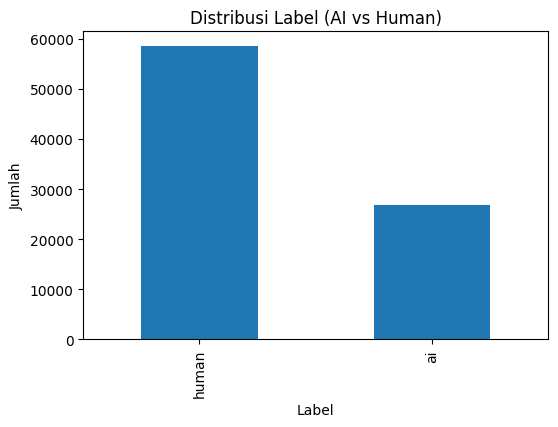

In [ ]:
print("Distribusi Label:\n", df["label"].value_counts())

df["label"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Distribusi Label (AI vs Human)")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()

## **Lihat Contoh Data per Label**

**Human**

In [ ]:
df[df['label'] == 'human'].head(3)

,question,answer,label
0,"Why is every book I hear about a "" NY Times # ...","Basically there are many categories of "" Best ...",human
1,"Why is every book I hear about a "" NY Times # ...","If you 're hearing about it , it 's because it...",human
2,"Why is every book I hear about a "" NY Times # ...","One reason is lots of catagories . However , h...",human


**AI**

In [ ]:
df[df['label'] == 'ai'].head(3)

,question,answer,label
3,"Why is every book I hear about a "" NY Times # ...",There are many different best seller lists tha...,ai
7,"If salt is so bad for cars , why do we use it ...",Salt is used on roads to help melt ice and sno...,ai
11,Why do we still have SD TV channels when HD lo...,There are a few reasons why we still have SD (...,ai


## **EDA Awal**

## **Cek kolom panjang teks (RAW)**

In [ ]:
df["raw_length"] = df["answer"].astype(str).apply(lambda x: len(x.split()))
df[["answer", "raw_length"]].head()

,answer,raw_length
0,"Basically there are many categories of "" Best ...",134
1,"If you 're hearing about it , it 's because it...",73
2,"One reason is lots of catagories . However , h...",62
3,There are many different best seller lists tha...,207
4,salt is good for not dying in car crashes and ...,41


## **Plot distribusi panjang teks (RAW)**

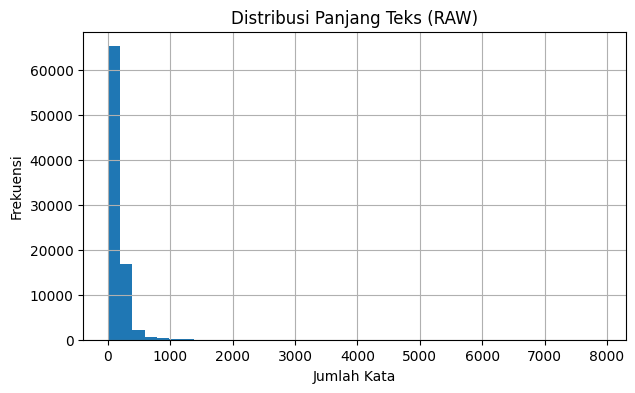

In [ ]:
df["raw_length"].hist(bins=40, figsize=(7,4))
plt.title("Distribusi Panjang Teks (RAW)")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

## **Top 10 kata paling sering (RAW)**

**Human**

In [ ]:
from collections import Counter

human_raw_text = " ".join(df[df["label"]=="human"]["answer"].astype(str))
human_counter = Counter(human_raw_text.split()).most_common(10)

print("Top 10 Kata (HUMAN - Raw):")
human_counter

Top 10 Kata (HUMAN - Raw):


[('the', 324568),
 ('.', 303101),
 (',', 271776),
 ('to', 193756),
 ('a', 176088),
 ('of', 163086),
 ('and', 153272),
 ('is', 126178),
 ('you', 99344),
 ('that', 96434)]

**AI**

In [ ]:
ai_raw_text = " ".join(df[df["label"]=="ai"]["answer"].astype(str))
ai_counter = Counter(ai_raw_text.split()).most_common(10)

print("Top 10 Kata (AI - Raw):")ai_counter

Top 10 Kata (AI - Raw):


[('the', 238679),
 ('to', 172654),
 ('and', 151316),
 ('a', 147697),
 ('of', 124733),
 ('is', 99547),
 ('that', 75406),
 ('in', 66762),
 ('or', 54494),
 ('are', 53839)]

## **Cek duplikat**

In [ ]:
print("Jumlah Data Duplikat:", df.duplicated().sum())

Jumlah Data Duplikat: 3019


## **Info data**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85449 entries, 0 to 85448
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   question    85449 non-null  object
 1   answer      85431 non-null  object
 2   label       85449 non-null  object
 3   raw_length  85449 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.6+ MB


# **PREPROCESSING**

## **Import library NLP**

In [ ]:
import re
import nltk
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("Library NLP siap ✔")

Library NLP siap ✔


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## **Inisialisasi stopwords & lemmatizer**

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("Stopwords dan Lemmatizer siap ✔")

Stopwords dan Lemmatizer siap ✔


## **Lowercase**

In [ ]:
df["cleaned"] = df["answer"].fillna("").astype(str).str.lower()
df[["answer", "cleaned"]].head()

,answer,cleaned
0,"Basically there are many categories of "" Best ...","basically there are many categories of "" best ..."
1,"If you 're hearing about it , it 's because it...","if you 're hearing about it , it 's because it..."
2,"One reason is lots of catagories . However , h...","one reason is lots of catagories . however , h..."
3,There are many different best seller lists tha...,there are many different best seller lists tha...
4,salt is good for not dying in car crashes and ...,salt is good for not dying in car crashes and ...


## **Punction & Symbol Removal**

In [ ]:
df["cleaned"] = df["cleaned"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", " ", x)
)
df[["answer", "cleaned"]].head()

,answer,cleaned
0,"Basically there are many categories of "" Best ...",basically there are many categories of best ...
1,"If you 're hearing about it , it 's because it...",if you re hearing about it it s because it...
2,"One reason is lots of catagories . However , h...",one reason is lots of catagories however h...
3,There are many different best seller lists tha...,there are many different best seller lists tha...
4,salt is good for not dying in car crashes and ...,salt is good for not dying in car crashes and ...


## **Normalization**

In [ ]:
df["cleaned"] = df["cleaned"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)
df[["answer", "cleaned"]].head()

,answer,cleaned
0,"Basically there are many categories of "" Best ...",basically there are many categories of best se...
1,"If you 're hearing about it , it 's because it...",if you re hearing about it it s because it was...
2,"One reason is lots of catagories . However , h...",one reason is lots of catagories however how t...
3,There are many different best seller lists tha...,there are many different best seller lists tha...
4,salt is good for not dying in car crashes and ...,salt is good for not dying in car crashes and ...


## **Tokenization**

In [ ]:
df["tokens"] = df["cleaned"].apply(lambda x: x.split())
df[["cleaned", "tokens"]].head()


,cleaned,tokens
0,basically there are many categories of best se...,"[basically, there, are, many, categories, of, ..."
1,if you re hearing about it it s because it was...,"[if, you, re, hearing, about, it, it, s, becau..."
2,one reason is lots of catagories however how t...,"[one, reason, is, lots, of, catagories, howeve..."
3,there are many different best seller lists tha...,"[there, are, many, different, best, seller, li..."
4,salt is good for not dying in car crashes and ...,"[salt, is, good, for, not, dying, in, car, cra..."


## **Stopword Removal**

In [ ]:
df["tokens"] = df["tokens"].apply(
    lambda words: [w for w in words if w not in stop_words]
)
df[["tokens"]].head()

,tokens
0,"[basically, many, categories, best, seller, re..."
1,"[hearing, good, well, publicized, book, almost..."
2,"[one, reason, lots, catagories, however, ny, t..."
3,"[many, different, best, seller, lists, publish..."
4,"[salt, good, dying, car, crashes, car, crashes..."


## **Lemmatization**

In [ ]:
df["tokens"] = df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(w) for w in words]
)
df[["tokens"]].head()

,tokens
0,"[basically, many, category, best, seller, repl..."
1,"[hearing, good, well, publicized, book, almost..."
2,"[one, reason, lot, catagories, however, ny, ti..."
3,"[many, different, best, seller, list, publishe..."
4,"[salt, good, dying, car, crash, car, crash, wo..."


## **Gabung kembali token**

In [ ]:
df["cleaned"] = df["tokens"].apply(lambda words: " ".join(words))
df[["answer", "cleaned"]].head()

,answer,cleaned
0,"Basically there are many categories of "" Best ...",basically many category best seller replace be...
1,"If you 're hearing about it , it 's because it...",hearing good well publicized book almost every...
2,"One reason is lots of catagories . However , h...",one reason lot catagories however ny time calc...
3,There are many different best seller lists tha...,many different best seller list published vari...
4,salt is good for not dying in car crashes and ...,salt good dying car crash car crash worse car ...


## **Tambahkan kolom panjang teks cleaned**

In [ ]:
df["clean_length"] = df["cleaned"].apply(lambda x: len(x.split()))
df[["cleaned", "clean_length"]].head()

,cleaned,clean_length
0,basically many category best seller replace be...,61
1,hearing good well publicized book almost every...,29
2,one reason lot catagories however ny time calc...,29
3,many different best seller list published vari...,111
4,salt good dying car crash car crash worse car ...,22


## **Save hasil**

In [ ]:
df.to_csv(OUTPUT_PATH + "cleaned_dataset.csv", index=False)
print("cleaned_dataset.csv berhasil disimpan ✔")

cleaned_dataset.csv berhasil disimpan ✔


# **EDA HASIL PREPROCESSING**

## **Cek 5 data setelah preprocessing**

In [ ]:
df[["answer", "cleaned"]].head()

,answer,cleaned
0,"Basically there are many categories of "" Best ...",basically many category best seller replace be...
1,"If you 're hearing about it , it 's because it...",hearing good well publicized book almost every...
2,"One reason is lots of catagories . However , h...",one reason lot catagories however ny time calc...
3,There are many different best seller lists tha...,many different best seller list published vari...
4,salt is good for not dying in car crashes and ...,salt good dying car crash car crash worse car ...


## **Distribusi Panjang teks (cleaned)**

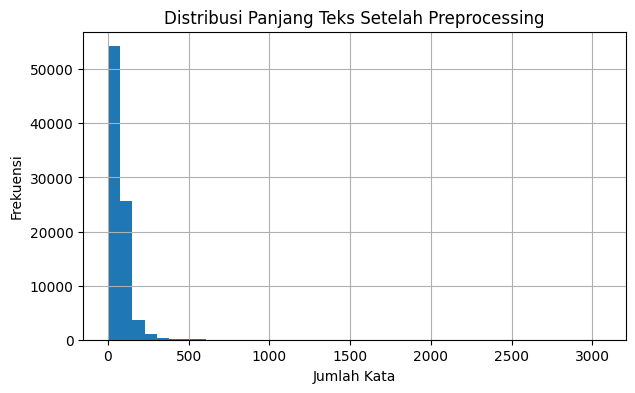

In [ ]:
df["clean_length"].hist(bins=40, figsize=(7,4))
plt.title("Distribusi Panjang Teks Setelah Preprocessing")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

## **Wordcloud Cleaned**

**Human**

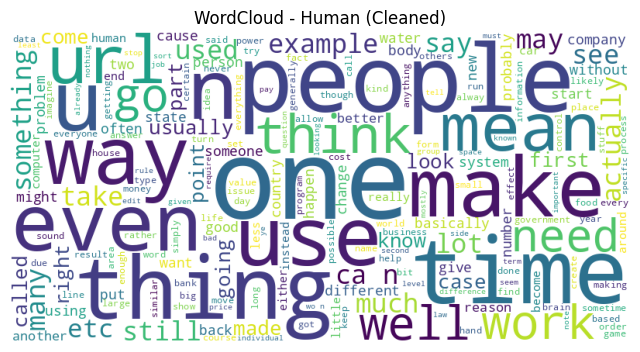

In [ ]:
from wordcloud import WordCloud

human_text_clean = " ".join(df[df["label"]=="human"]["cleaned"])

plt.figure(figsize=(8,5))
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(human_text_clean))
plt.title("WordCloud - Human (Cleaned)")
plt.axis("off")
plt.show()

**AI**

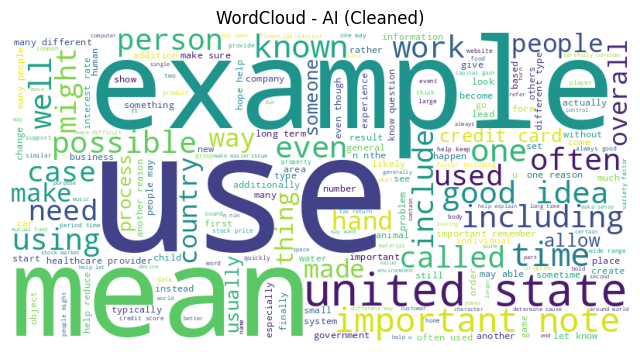

In [ ]:
ai_text_clean = " ".join(df[df["label"]=="ai"]["cleaned"])

plt.figure(figsize=(8,5))
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(ai_text_clean))
plt.title("WordCloud - AI (Cleaned)")
plt.axis("off")
plt.show()

## **Top 20 kata cleaned**

**Human**

/tmp/ipython-input-2700496380.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=human_df, x="count", y="word", palette="Greens_r")


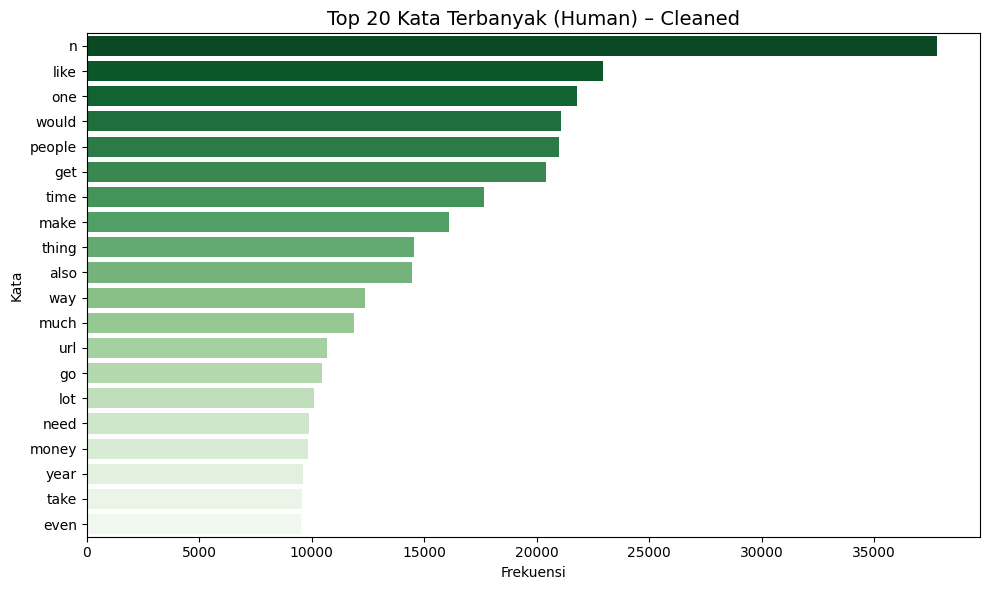

In [ ]:
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

human_tokens = (t for row in df[df["label"]=="human"]["tokens"] for t in row)
human_top20 = Counter(human_tokens).most_common(20)

human_df = pd.DataFrame(human_top20, columns=["word", "count"])

plt.figure(figsize=(10,6))
sns.barplot(data=human_df, x="count", y="word", palette="Greens_r")
plt.title("Top 20 Kata Terbanyak (Human) – Cleaned", fontsize=14)
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.tight_layout()
plt.show()

**AI**

/tmp/ipython-input-4224832325.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ai_df, x="count", y="word", palette="Blues_r")


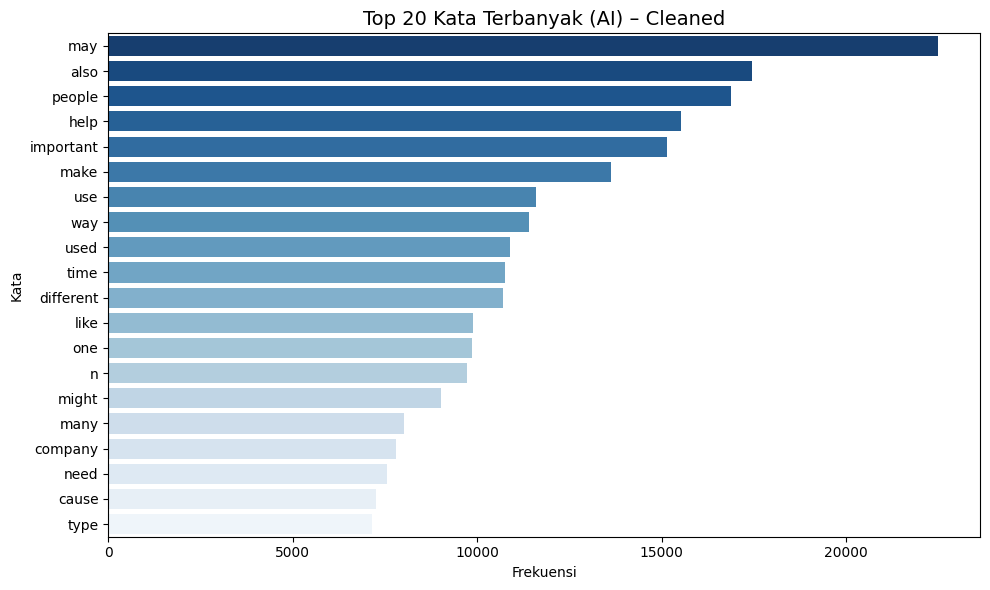

In [ ]:
ai_tokens = (t for row in df[df["label"]=="ai"]["tokens"] for t in row)
ai_top20 = Counter(ai_tokens).most_common(20)

ai_df = pd.DataFrame(ai_top20, columns=["word", "count"])

plt.figure(figsize=(10,6))
sns.barplot(data=ai_df, x="count", y="word", palette="Blues_r")
plt.title("Top 20 Kata Terbanyak (AI) – Cleaned", fontsize=14)
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.tight_layout()
plt.show()

## **Contoh teks sebelum & sesudah preprocessing**

In [ ]:
df[["answer", "cleaned"]].sample(5)

,answer,cleaned
29485,"It was n't always that way , once upon a time ...",n always way upon time player developer fairly...
81076,"Having dealt with with Social Security, state ...",dealt social security state agency bank care w...
23292,"First , it 's safer . You avoid vehicles hitti...",first safer avoid vehicle hitting storage tank...
43687,"When you build up anxiety and anger , adrenali...",build anxiety anger adrenaline released adrena...
9572,"When a computer writes something to a disk , l...",computer writes something disk like installing...


## **Plot perbandingan panjang RAW vs CLEANED**

/tmp/ipython-input-1469458718.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["raw_length"], label="RAW", shade=True)
/tmp/ipython-input-1469458718.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["clean_length"], label="Cleaned", shade=True)


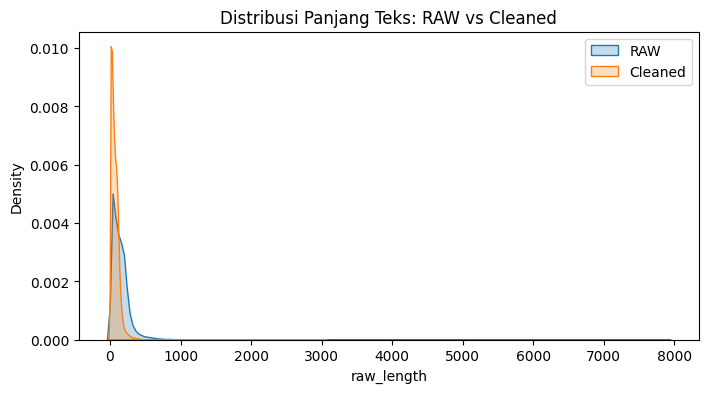

In [ ]:
plt.figure(figsize=(8,4))
sns.kdeplot(df["raw_length"], label="RAW", shade=True)
sns.kdeplot(df["clean_length"], label="Cleaned", shade=True)
plt.title("Distribusi Panjang Teks: RAW vs Cleaned")
plt.legend()
plt.show()

## **Distribusi label setelah preprocessing**

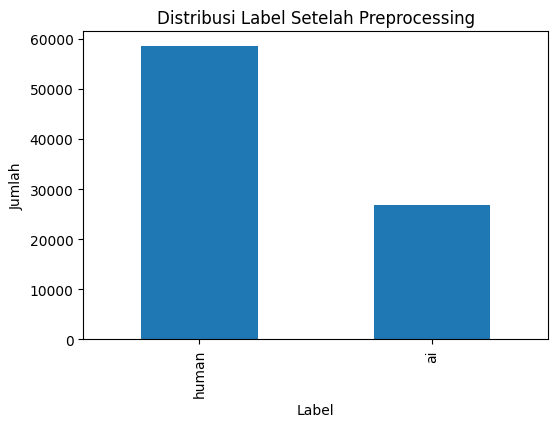

In [ ]:
df["label"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Distribusi Label Setelah Preprocessing")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.show()

## **Save hasil preprocessing**

In [ ]:
df.to_csv(OUTPUT_PATH + "cleaned_dataset.csv", index=False)
print("cleaned_dataset.csv berhasil disimpan ✔")

cleaned_dataset.csv berhasil disimpan ✔


# **FEATURE ENGINEERING**

## **Import TF-IDF vectorizer**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF library siap ✔")

TF-IDF library siap ✔


## **TD-IDF training**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

X = tfidf.fit_transform(df["cleaned"])
y = df["label"]

print("TF-IDF berhasil ✔")
print("Shape:", X.shape)

TF-IDF berhasil ✔
Shape: (85449, 5000)


## **Cek x**

In [ ]:
try:
    X.shape
    print("X ADA ✔")
except:
    print("X TIDAK ADA ❌")

X ADA ✔


# **EDA FEATURE ENGINEERING**

## **Vocabulary Size**

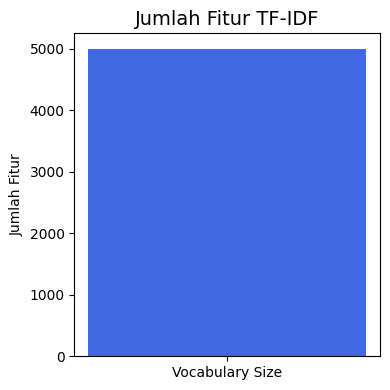

Vocabulary Size: 5000


In [ ]:
vocab_size = len(tfidf.get_feature_names_out())

plt.figure(figsize=(4,4))
plt.bar(["Vocabulary Size"], [vocab_size], color="royalblue")
plt.title("Jumlah Fitur TF-IDF", fontsize=14)
plt.ylabel("Jumlah Fitur")
plt.tight_layout()
plt.show()

print("Vocabulary Size:", vocab_size)

## **Top 20 fitur TF-IDF**

/tmp/ipython-input-1789646779.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette="Purples_r")


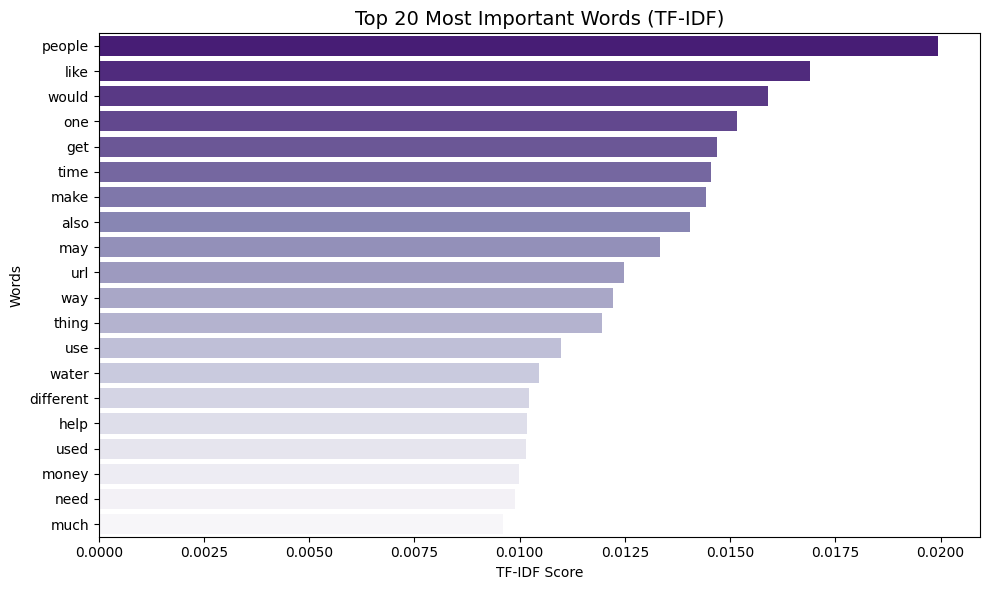

In [ ]:
import numpy as np

feature_means = np.mean(X.toarray(), axis=0)
top_idx = feature_means.argsort()[-20:][::-1]

top_words = [tfidf.get_feature_names_out()[i] for i in top_idx]
top_scores = feature_means[top_idx]

plt.figure(figsize=(10,6))
sns.barplot(x=top_scores, y=top_words, palette="Purples_r")
plt.title("Top 20 Most Important Words (TF-IDF)", fontsize=14)
plt.xlabel("TF-IDF Score")
plt.ylabel("Words")
plt.tight_layout()
plt.show()

In [ ]:
try:
    print("X shape =", X.shape)
except:
    print("X HILANG ❌ — jalankan TF-IDF lagi!")

X shape = (85449, 5000)


## **Hitung feature_means**

In [ ]:
feature_means = np.mean(X.toarray(), axis=0)
print("feature_means dibuat ✔")

feature_means dibuat ✔


## **Cek sparsity (Kerapatan matrix)**

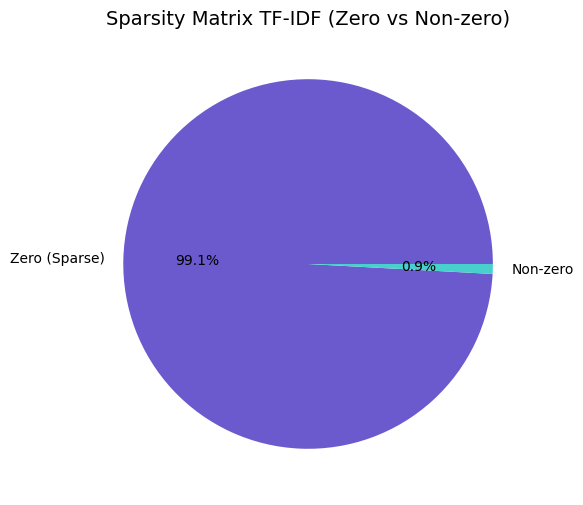

Sparsity: 0.9914 (99.14%)


In [ ]:
total_elements = X.shape[0] * X.shape[1]
nonzero_elements = X.nnz
zero_elements = total_elements - nonzero_elements

sparsity = zero_elements / total_elements

plt.figure(figsize=(6,6))
plt.pie(
    [zero_elements, nonzero_elements],
    labels=["Zero (Sparse)", "Non-zero"],
    autopct="%1.1f%%",
    colors=["#6A5ACD", "#48D1CC"]
)
plt.title("Sparsity Matrix TF-IDF (Zero vs Non-zero)", fontsize=14)
plt.show()

print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")

## **Heatmap Sample TD-IDF vector**

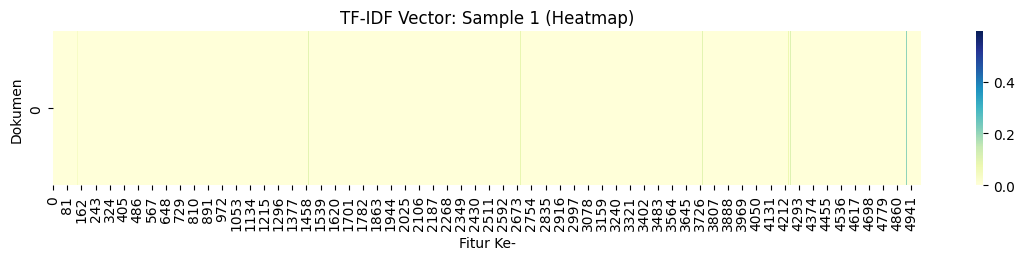

In [ ]:
import numpy as np

sample_vec = X.toarray()[0].reshape(1, -1)

plt.figure(figsize=(14,2))
sns.heatmap(sample_vec, cmap="YlGnBu", cbar=True)
plt.title("TF-IDF Vector: Sample 1 (Heatmap)")
plt.xlabel("Fitur Ke-")
plt.ylabel("Dokumen")
plt.show()

## **Distribusi nilai TF-IDF**

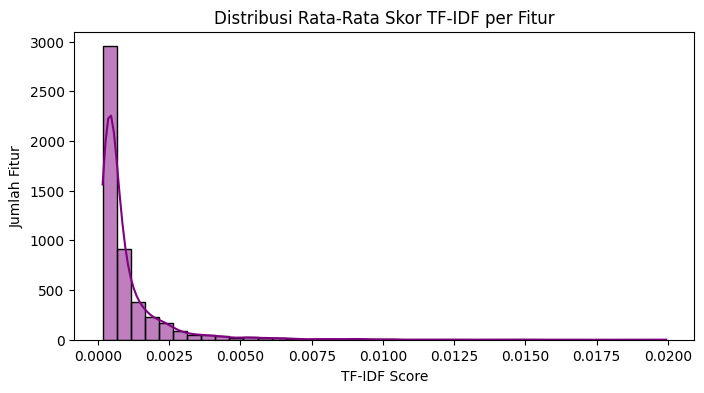

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(feature_means, bins=40, kde=True, color="purple")
plt.title("Distribusi Rata-Rata Skor TF-IDF per Fitur")
plt.xlabel("TF-IDF Score")
plt.ylabel("Jumlah Fitur")
plt.show()

## **Save hasil**

In [ ]:
tfidf_df = pd.DataFrame(X.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df.to_csv(OUTPUT_PATH + "tfidf_features.csv", index=False)
print("TF-IDF Saved.")

# **MODELING**

## **Train-Test**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (68359, 5000)
Test size: (17090, 5000)


## **Logistic Regression (Model 1)**

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)

print("Logistic Regression trained ✔")

Logistic Regression trained ✔


## **Evaluasi Logistic Regression**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_logreg = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))

Accuracy: 0.9459332943241662

Classification Report:
               precision    recall  f1-score   support

          ai       0.94      0.89      0.91      5381
       human       0.95      0.97      0.96     11709

    accuracy                           0.95     17090
   macro avg       0.94      0.93      0.94     17090
weighted avg       0.95      0.95      0.95     17090



## **Confusion Matrix Logistic Regression (Grafik)**

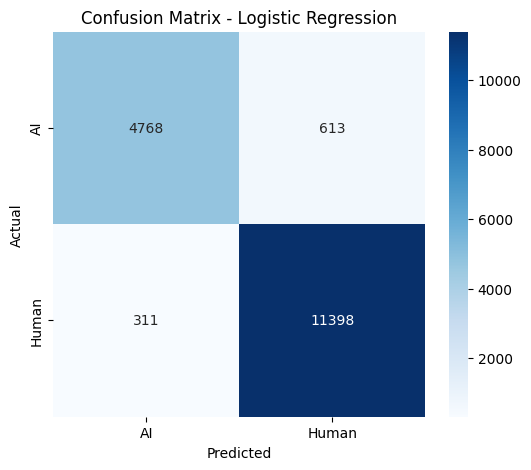

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["AI", "Human"], yticklabels=["AI", "Human"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **SVM (Linear SVC) (Model 2)**

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

print("SVM trained ✔")

SVM trained ✔


## **Evaluasi SVM**

In [ ]:
y_pred_svm = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Accuracy: 0.9545348156816852

Classification Report:
               precision    recall  f1-score   support

          ai       0.94      0.92      0.93      5381
       human       0.96      0.97      0.97     11709

    accuracy                           0.95     17090
   macro avg       0.95      0.94      0.95     17090
weighted avg       0.95      0.95      0.95     17090



## **Confusion Matrix SVM (Grafik)**

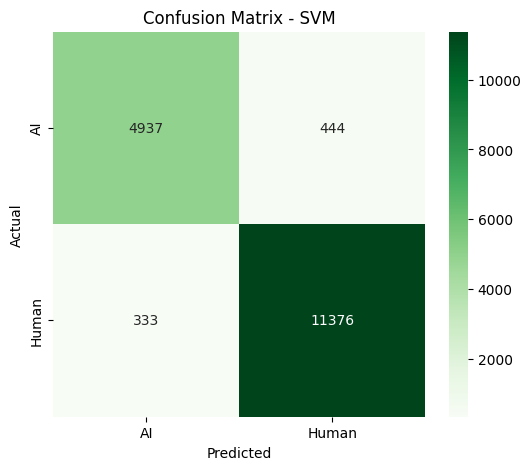

In [ ]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["AI", "Human"], yticklabels=["AI", "Human"])
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **ROC Curve & AUC (Khusus Binary Classification)**

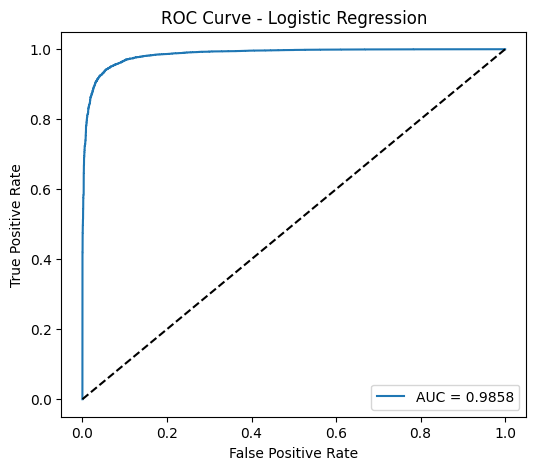

AUC Score: 0.9857698447082822


In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = logreg.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label="human")
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

print("AUC Score:", roc_auc)

## **Menetukan Model Terbaik**

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

if accuracy_score(y_test, y_pred_svm) > accuracy_score(y_test, y_pred_logreg):
    print("\nModel Terbaik: SVM ✔")
else:
    print("\nModel Terbaik: Logistic Regression ✔")

Logistic Regression Accuracy: 0.9459332943241662
SVM Accuracy: 0.9545348156816852

Model Terbaik: SVM ✔
